# 01 · Exploratory data analysis

Before modeling, we want to understand the survey responses:

1. **Data quality**: is the data clean, and are there duplicates or contradictions?
2. **Class balance**: what accuracy do we get without a model?
3. **Answer distributions**: how did customers answer each question?
4. **Answers vs. happiness**: which questions separate happy from unhappy customers?
5. **Redundancy**: do some questions measure the same thing?

In [2]:
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from scipy.stats import mannwhitneyu
from sklearn.feature_selection import mutual_info_classif

from happiness.config import FEATURES, FIGURES_DIR, QUESTIONS, TARGET
from happiness.data import load_data

BLUE, LIGHT_BLUE = "#2a78d6", "#b7d3f6"
ANSWER_COLORS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # answers 1 -> 5
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "axes.titleweight": "bold",
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "axes.axisbelow": True,
    }
)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def label(feature: str, width: int = 60) -> str:
    return textwrap.fill(f"{feature} · {QUESTIONS[feature]}", width)

## 1. Data quality

`load_data()` validates the file on load: every column is present, there are no missing values,
answers are whole numbers from 1 to 5, and `Y` is 0 or 1. If any check failed, the next cell
would raise an error.

In [2]:
df = load_data()
print(f"{df.shape[0]} customers, {df.shape[1] - 1} questions")
df.head()

126 customers, 6 questions


,X1,X2,X3,X4,X5,X6,Y
0,3,3,3,4,2,4,0
1,3,2,3,5,4,3,0
2,5,3,3,3,3,5,1
3,5,4,3,3,3,5,0
4,5,4,3,3,3,5,0


In [3]:
df[FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
X1,126.0,4.33,0.80,1.0,4.0,5.0,5.0,5.0
X2,126.0,2.53,1.11,1.0,2.0,3.0,3.0,5.0
X3,126.0,3.31,1.02,1.0,3.0,3.0,4.0,5.0
X4,126.0,3.75,0.88,1.0,3.0,4.0,4.0,5.0
X5,126.0,3.65,1.15,1.0,3.0,4.0,4.0,5.0
X6,126.0,4.25,0.81,1.0,4.0,4.0,5.0,5.0


### Duplicates and contradictions

With 6 questions and 5 possible answers, different customers can easily give identical
answers. So duplicate rows are real responses, not data-entry errors, and we **keep** them.
Dropping them would change the class distribution.

More interesting are *contradictions*: identical answers with different labels. No model can
classify all of those customers correctly, so they set an upper bound on achievable accuracy.

In [4]:
patterns = df.groupby(FEATURES)[TARGET].agg(customers="size", happy="sum")
conflicting = patterns[(patterns.happy > 0) & (patterns.happy < patterns.customers)]

print(f"Duplicate rows:          {df.duplicated().sum()}")
print(f"Unique answer patterns:  {len(patterns)} (for {len(df)} customers)")
print(f"Contradictory patterns:  {len(conflicting)} ({conflicting.customers.sum()} customers)")
conflicting

Duplicate rows:          16
Unique answer patterns:  103 (for 126 customers)
Contradictory patterns:  7 (17 customers)


customers  happy
X1 X2 X3 X4 X5 X6                  
4  2  3  3  4  4           2      1
      4  4  4  4           3      1
   3  3  4  2  4           2      1
5  2  3  3  2  5           2      1
      4  4  5  5           3      2
   3  3  3  5  3           2      1
         4  4  5           3      2

- 103 of 126 answer patterns are unique, so a model cannot just memorize patterns. It has to
  learn general relationships.
- 17 customers fall into 7 contradictory patterns (identical answers, different happiness).
  This is irreducible noise: happiness depends on things the survey does not ask about.

## 2. Class balance

In [5]:
counts = df[TARGET].value_counts().sort_index()
balance = pd.DataFrame({"customers": counts, "share": (counts / len(df)).round(3)})
balance.index = balance.index.map({0: "unhappy (0)", 1: "happy (1)"})
balance

,customers,share
Y,,
unhappy (0),57,0.452
happy (1),69,0.548


The classes are roughly balanced (55% happy, 45% unhappy), so accuracy is a meaningful metric
and we don't need resampling.

**Baseline: always predicting "happy" scores 54.8%.** Any model has to clearly beat this.

## 3. How customers answered

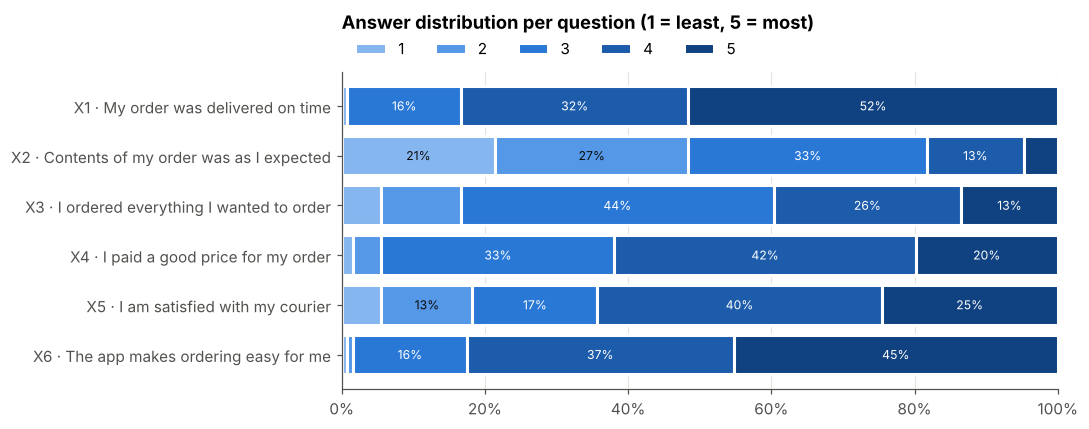

In [6]:
shares = (
    df[FEATURES]
    .apply(lambda col: col.value_counts(normalize=True))
    .reindex(range(1, 6))
    .fillna(0)
    .T
)

fig, ax = plt.subplots(figsize=(10, 4))
left = pd.Series(0.0, index=FEATURES)
for answer, color in zip(shares.columns, ANSWER_COLORS, strict=True):
    ax.barh(
        [label(f) for f in FEATURES],
        shares[answer],
        left=left,
        color=color,
        edgecolor="white",
        linewidth=2,
        label=str(answer),
    )
    for i, feature in enumerate(FEATURES):
        share = shares.loc[feature, answer]
        if share >= 0.12:
            ax.text(
                left[feature] + share / 2,
                i,
                f"{share:.0%}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if answer >= 3 else INK,
            )
    left += shares[answer]

ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.grid(axis="y", visible=False)
ax.set_title("Answer distribution per question (1 = least, 5 = most)", loc="left", pad=28)
ax.legend(ncols=5, loc="lower left", bbox_to_anchor=(0, 1.0), frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "answer_distribution.png", bbox_inches="tight")
plt.show()

- **X1 (on time)** and **X6 (app)** are rated high by most customers (mostly 4–5), so there's
  little variation left to learn from.
- **X2 (contents as expected)** is the lowest-rated question: about half of customers answer 1–2.
- **X3 (ordered everything)** clusters at 3.
- Very low answers (1–2) are rare for most questions. Groups that small (fewer than 5 customers)
  give unreliable estimates in the next section.

## 4. Happiness by answer

For each question: of the customers who gave answer *k*, what share are happy? If a question
matters, this share should rise with the answer.

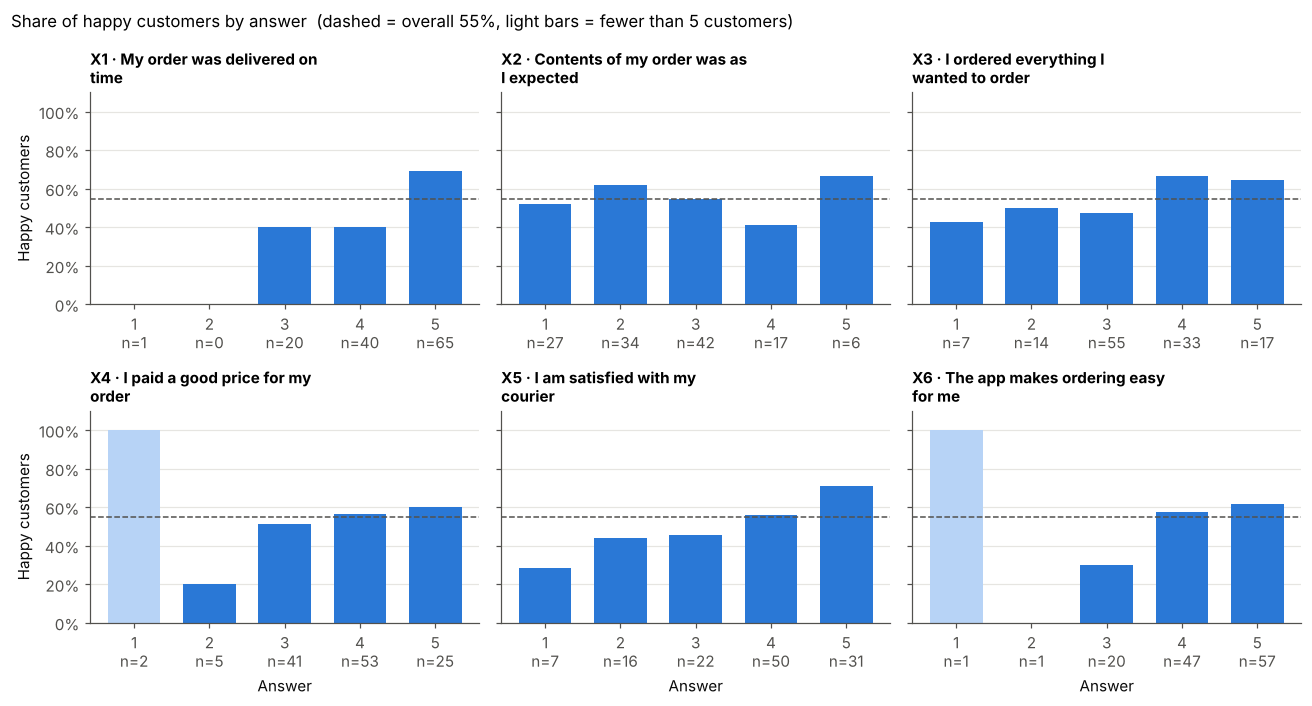

In [7]:
overall = df[TARGET].mean()

fig, axes = plt.subplots(2, 3, figsize=(12, 6.5), sharey=True)
for ax, feature in zip(axes.flat, FEATURES, strict=True):
    stats = df.groupby(feature)[TARGET].agg(rate="mean", n="size")
    colors = [BLUE if n >= 5 else LIGHT_BLUE for n in stats.n]
    ax.bar(stats.index, stats.rate, color=colors, width=0.7)
    ax.axhline(overall, color=MUTED, linestyle="--", linewidth=1)
    ax.set_title(label(feature, width=32), loc="left", fontsize=10)
    n_per_answer = stats.n.reindex(range(1, 6), fill_value=0)
    ax.set_xticks(range(1, 6), [f"{k}\nn={n}" for k, n in n_per_answer.items()])
    ax.set_ylim(0, 1.1)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(axis="x", visible=False)

for ax in axes[:, 0]:
    ax.set_ylabel("Happy customers")
for ax in axes[1]:
    ax.set_xlabel("Answer")
fig.suptitle(
    f"Share of happy customers by answer  (dashed = overall {overall:.0%}, "
    "light bars = fewer than 5 customers)",
    x=0.01,
    ha="left",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "happiness_by_answer.png", bbox_inches="tight")
plt.show()

- **X1 (delivered on time)** is the clearest signal, and it acts like a yes/no switch. 69% of
  customers who answered 5 are happy, versus 40% of those who answered 3 or 4. "On time"
  seems to matter only when delivery was *fully* on time. That suggests trying a top-box
  feature (answer = 5) during modeling.
- **X5 (courier)** rises steadily, from 29% happy at answer 1 to 71% at answer 5.
- **X6 (app)** and **X3 (ordered everything)** show a moderate step up for answers 4–5.
- **X4 (price)** is nearly flat once the tiny groups are ignored.
- **X2 (contents as expected)** shows no pattern at all.

## 5. Strength of association with happiness

Three complementary measures for each question:

- **Spearman r**: does happiness tend to rise as the answer rises (monotonic relationship)?
- **Mutual information**: how much does knowing the answer reduce uncertainty about happiness?
  This captures non-monotonic relationships too.
- **Mann–Whitney p-value**: how likely is a difference this large between happy and unhappy
  customers if the question had no real effect? With only 126 customers, this protects us
  from reading too much into noise.

In [8]:
X, y = df[FEATURES], df[TARGET]

association = pd.DataFrame(
    {
        "question": [QUESTIONS[f] for f in FEATURES],
        "mean_unhappy": X[y == 0].mean(),
        "mean_happy": X[y == 1].mean(),
        "spearman_r": X.corrwith(y, method="spearman"),
        "mutual_info": mutual_info_classif(X, y, discrete_features=True, random_state=0),
        "mann_whitney_p": [
            mannwhitneyu(X.loc[y == 1, f], X.loc[y == 0, f]).pvalue for f in FEATURES
        ],
    },
    index=FEATURES,
)
association.sort_values("spearman_r", ascending=False).round(3)

,question,mean_unhappy,mean_happy,spearman_r,mutual_info,mann_whitney_p
X1,My order was delivered on time,4.088,4.536,0.291,0.050,0.001
X5,I am satisfied with my courier,3.368,3.884,0.227,0.028,0.011
X6,The app makes ordering easy for me,4.105,4.377,0.174,0.036,0.052
X3,I ordered everything I wanted to order,3.140,3.449,0.162,0.017,0.070
X4,I paid a good price for my order,3.684,3.797,0.081,0.022,0.364
X2,Contents of my order was as I expected,2.561,2.507,-0.034,0.009,0.703


- Only **X1** (p = 0.001) and **X5** (p = 0.011) differ significantly between happy and unhappy
  customers at the 5% level.
- **X6** (p = 0.052) and **X3** (p = 0.070) are borderline.
- **X4** (p = 0.36) and **X2** (p = 0.70) show no evidence of a relationship.
- Both Spearman r and mutual information put X1 first and X2 last.

**Caveat:** these are one-question-at-a-time views. A question can still add information in
combination with others (or be redundant with them). Milestone 3 tests this with models.

## 6. Redundancy between questions

If two questions are strongly correlated, they carry overlapping information. One of them may
be removable without losing predictive power.

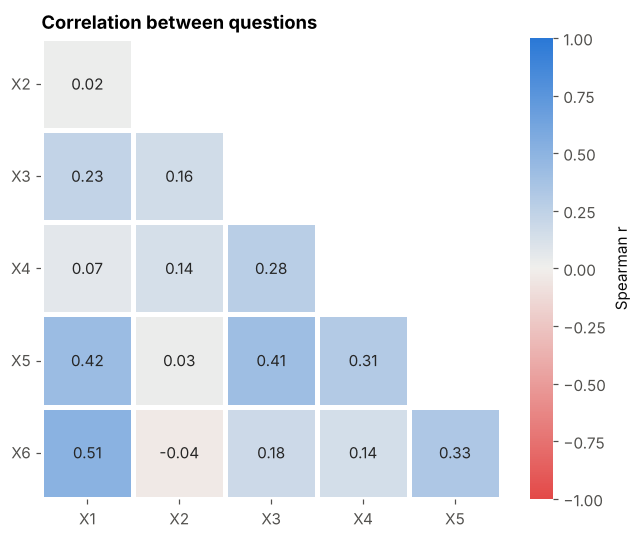

In [9]:
# Each pair once: drop the diagonal and the mirrored upper triangle.
corr = X.corr(method="spearman").iloc[1:, :-1]
upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = LinearSegmentedColormap.from_list("diverging", ["#e34948", "#f0efec", BLUE])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    mask=upper,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=2,
    linecolor="white",
    cbar_kws={"label": "Spearman r"},
    ax=ax,
)
ax.grid(False)
ax.tick_params(axis="y", rotation=0)
ax.set_title("Correlation between questions", loc="left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "question_correlation.png", bbox_inches="tight")
plt.show()

- No pair is strongly correlated (all |r| ≤ 0.51), so no question is a pure duplicate of another.
- **X1–X6 (0.51)**, **X1–X5 (0.42)** and **X3–X5 (0.41)** overlap moderately. Part of what
  X6 tells us may already be in X1, so X6 could look useful alone but add little on top of X1.
- **X2** is nearly uncorrelated with every other question *and* with happiness.

## Summary

| Question | Evidence of a link to happiness | Early verdict |
|---|---|---|
| X1 · delivered on time | strong (p = 0.001), top-box effect at 5 | keep |
| X5 · satisfied with courier | clear, monotonic (p = 0.011) | keep |
| X6 · app makes ordering easy | moderate, overlaps with X1 | test in M3 |
| X3 · ordered everything I wanted | moderate (p = 0.07) | test in M3 |
| X4 · paid a good price | weak (p = 0.36) | removal candidate |
| X2 · contents as expected | none (p = 0.70) | removal candidate |

**Implications for modeling (M2):**

- The data is small (126 rows) and noisy (contradictory labels). A single train/test split
  would give an unreliable accuracy, so we use repeated cross-validation.
- Simple models (logistic regression, shallow trees) are likely to compete with complex ones.
- Worth testing a top-box encoding (answer = 5) alongside the raw 1–5 scale.

**Business note on X2:** it's the lowest-rated question yet unrelated to happiness. Customers
may read it ambiguously ("as expected" could be good or bad), so it may be worth *rewording*
rather than just dropping.